In [ ]:
%pip install nnfs

In [ ]:
import numpy as np
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

In [ ]:
class Dense:
    def __init__(self, n_inputs, n_neurons):  # n_inputs = amount of features
        self.weights = np.random.randn(
            n_inputs, n_neurons
        )  # generate random weights from normal standard distribution
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        self.inputs = inputs

    def backward(self, dvalues):  # dvalues has dimension (n_samples, n_outputs)
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dinputs = np.dot(
            dvalues, self.weights.T
        )  # dinputs will be propagated backwards through the layers
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)


class ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)
        self.inputs = inputs

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0


class LeakyRelu:  # mitigates dying relu problem
    def forward(self, inputs):
        self.output = np.maximum(inputs * 0.05, inputs)
        self.inputs = inputs

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] *= 0.05


class Sigmoid:  # return 0 to 1
    def forward(self, inputs):
        self.output = 1 / (1 + np.exp(-inputs))

    def backward(self, dvalues):
        self.dinputs = self.output * (1 - self.output) * dvalues


class Linear:  # does nothing
    def forward(self, inputs):
        self.output = inputs

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()


class Tanh:  # returns -1 to 1
    def forward(self, inputs):
        self.output = (np.exp(inputs) - np.exp(-inputs)) / (
            np.exp(inputs) + np.exp(-inputs)
        )

    def backward(self, dvalues):
        self.dinputs = (1 - self.output**2) * dvalues


class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss


class CategoricalCrossEntropy(Loss):
    def forward(self, prob_pred, y_true):
        samples = len(prob_pred)
        prob_pred_clipped = np.clip(prob_pred, 1e-7, 1 - 1e-7)

        if len(y_true.shape) == 1:
            correct_conf = prob_pred_clipped[range(samples), y_true]
        elif len(y_true.shape) == 2:
            correct_conf = np.sum(prob_pred_clipped * y_true, axis=1)

        return -np.log(correct_conf)

    def backward(self, dvalues, y_true):
        n = len(dvalues)

        if len(y_true.shape) == 1:
            labels = len(dvalues[0])
            y_true = np.eye(labels)[y_true]

        self.dinputs = (
            -y_true / dvalues / n
        )  # we want a small gradient by averaging or normalising


class Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

    def backward(self, dvalues):
        self.dinputs = np.empty_like(dvalues)
        for i, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            single_output = single_output.reshape(
                -1, 1
            )  # change dimension of vector to matrix 1D
            jacobian_matrix = np.diagflat(single_output) - np.dot(
                single_output, single_output.T
            )
            self.dinputs[i] = np.dot(jacobian_matrix, single_dvalues)


# Instead of doing backpropagation on Softmax and Loss individually, we can just
# call the backpropagation of Softmax + Loss as the backward becomes easier
class CalcSoftmaxLossGrad:
    def __init__(self):
        self.activation = Softmax()
        self.loss = CategoricalCrossEntropy()

    def forward(self, inputs, y):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output, y)

    def backward(self, dvalues, y_true):
        n = len(dvalues)
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        self.dinputs = dvalues.copy()
        self.dinputs[range(n), y_true] -= 1  # softmax_output - y_true
        self.dinputs = self.dinputs / n


class Optimizer_SGD:
    def __init__(self, learning_rate=0.1, decay=0, momentum=0):
        self.learning_rate = learning_rate
        self.decay = decay
        self.current_learning_rate = learning_rate
        self.iterations = 0
        self.momentum = momentum

    def pre_update_params(self):  # add time-based decay for learning_rate
        if self.decay:
            self.current_learning_rate = self.learning_rate * (
                1 / (1 + self.iterations * self.decay)
            )

    def update_params(self, layer):
        if self.momentum:
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)

            weight_updates = (
                self.momentum * layer.weight_momentums
                - self.current_learning_rate * layer.dweights
            )
            layer.weight_momentums = weight_updates

            bias_updates = (
                self.momentum * layer.bias_momentums
                - self.current_learning_rate * layer.dbiases
            )
            layer.bias_momentums = bias_updates

        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases

        layer.weights += weight_updates
        layer.biases += bias_updates

    def post_update_params(self):
        self.iterations += 1

In [ ]:
# large x values for exp may cause overflow, hence why we need to normalize it
np.exp(100)

2.6881171418161356e+43

## Testing with Simple Input


In [ ]:
inputs = [[-1, 2, 3], [3, -4, 5]]

n_neurons1 = 10

# initialize activation function
relu = ReLU()
softmax = Softmax()

# make single dense layer
dense1 = Dense(np.array(inputs).shape[1], n_neurons1)

In [ ]:
dense1.biases

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
dense1.forward(inputs)
dense1.output

array([[ 2.39924023, -4.37091578, -2.65470078, -1.47022164,  0.9750476 ,
         4.86327365,  7.298892  , -4.77616395,  1.28963826,  6.15863392],
       [ 2.25202624, -6.27878086, -9.15268376,  5.48321445,  1.91580023,
        10.73922051,  7.70129448,  7.07845609,  0.8777502 , 20.47751699]])

In [ ]:
relu.forward(dense1.output)
relu.output

array([[ 2.39924023,  0.        ,  0.        ,  0.        ,  0.9750476 ,
         4.86327365,  7.298892  ,  0.        ,  1.28963826,  6.15863392],
       [ 2.25202624,  0.        ,  0.        ,  5.48321445,  1.91580023,
        10.73922051,  7.70129448,  7.07845609,  0.8777502 , 20.47751699]])

In [ ]:
dense1.weights

array([[ 0.05024964, -0.05778553,  0.10540231,  1.51819499,  0.13862554,
         1.2929808 ,  0.45680742,  0.4070453 ,  0.03783599,  1.22238898],
       [ 0.27016443, -0.17396517,  0.71182635, -0.11572826,  0.04857249,
         0.46365627,  0.8993582 , -1.79170699,  0.19748384, -0.61481526],
       [ 0.63638701, -1.36025699, -1.32431706,  0.09314329,  0.33884272,
         1.74298064,  1.985661  , -0.26190156,  0.31083552,  2.8702178 ]])

In [ ]:
# make more than one dense layer and connect them
n_neurons2 = 5

dense2 = Dense(n_neurons1, n_neurons2)
dense2.forward(relu.output)
dense2.output

array([[ -2.58547337,  -8.51061807,  -1.25655414,  13.17517615,
         16.49792666],
       [ 22.86824536, -14.86822355, -21.29756588,  70.08329922,
         28.32584318]])

In [ ]:
dense2.output.shape

(2, 5)

In [ ]:
softmax.forward(dense2.output)
softmax.output

array([[4.97510744e-09, 1.32906070e-11, 1.87907775e-08, 3.47989053e-02,
        9.65201071e-01],
       [3.12437133e-21, 1.27650473e-37, 2.05965526e-40, 1.00000000e+00,
        7.32769297e-19]])

In [ ]:
np.sum(softmax.output, axis=1, keepdims=True)

array([[1.],
       [1.]])

## Testing on dummy dataset


In [ ]:
# x = 2D coordinates
# y = labels (correspond to which spiral arm)
[x, y] = spiral_data(samples=200, classes=3)

In [ ]:
x.shape

(600, 2)

In [ ]:
x[5, :]

array([-0.01416931,  0.02074916])

In [ ]:
y.shape

(600,)

In [ ]:
np.unique(y)

array([0, 1, 2], dtype=uint8)

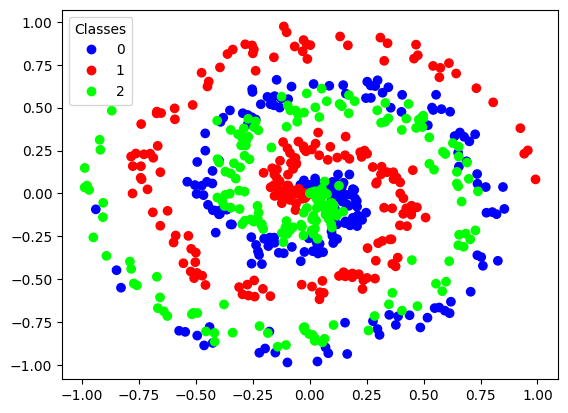

In [ ]:
# Create a scatter plot
scatter = plt.scatter(x[:, 0], x[:, 1], c=y, cmap="brg")

# Create a legend
handles, labels = scatter.legend_elements()
plt.legend(handles, [f"{int(label)}" for label in np.unique(y)], title="Classes")

# Show the plot
plt.show()

In [ ]:
# initialize loss function
softmax_loss = CalcSoftmaxLossGrad()

# initialize activation function
relu = ReLU()
softmax = Softmax()

# initialize layers
dense1 = Dense(x.shape[1], 64)
dense2 = Dense(64, 3)

# initialize optimizer
optimizer = Optimizer_SGD(0.2, 0.001, 0.9)

In [ ]:
n_epochs = 10000
monitor = np.zeros((n_epochs, 2))

for e in range(n_epochs):
    # forward propagation
    dense1.forward(x)
    relu.forward(dense1.output)
    dense2.forward(relu.output)
    loss = softmax_loss.forward(dense2.output, y)

    # get the accuracy
    predictions = np.argmax(softmax_loss.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    # backward propagation
    softmax_loss.backward(softmax_loss.output, y)
    dense2.backward(softmax_loss.dinputs)
    relu.backward(dense2.dinputs)
    dense1.backward(relu.dinputs)

    optimizer.update_params(dense1)
    optimizer.update_params(dense2)

    monitor[e, 0] = loss
    monitor[e, 1] = accuracy

# print the loss and accuracy
print(f"Loss: {loss}, Accuracy: {accuracy}")

Loss: 0.22858002289752372, Accuracy: 0.91


Text(0.5, 1.0, 'Accuracy')

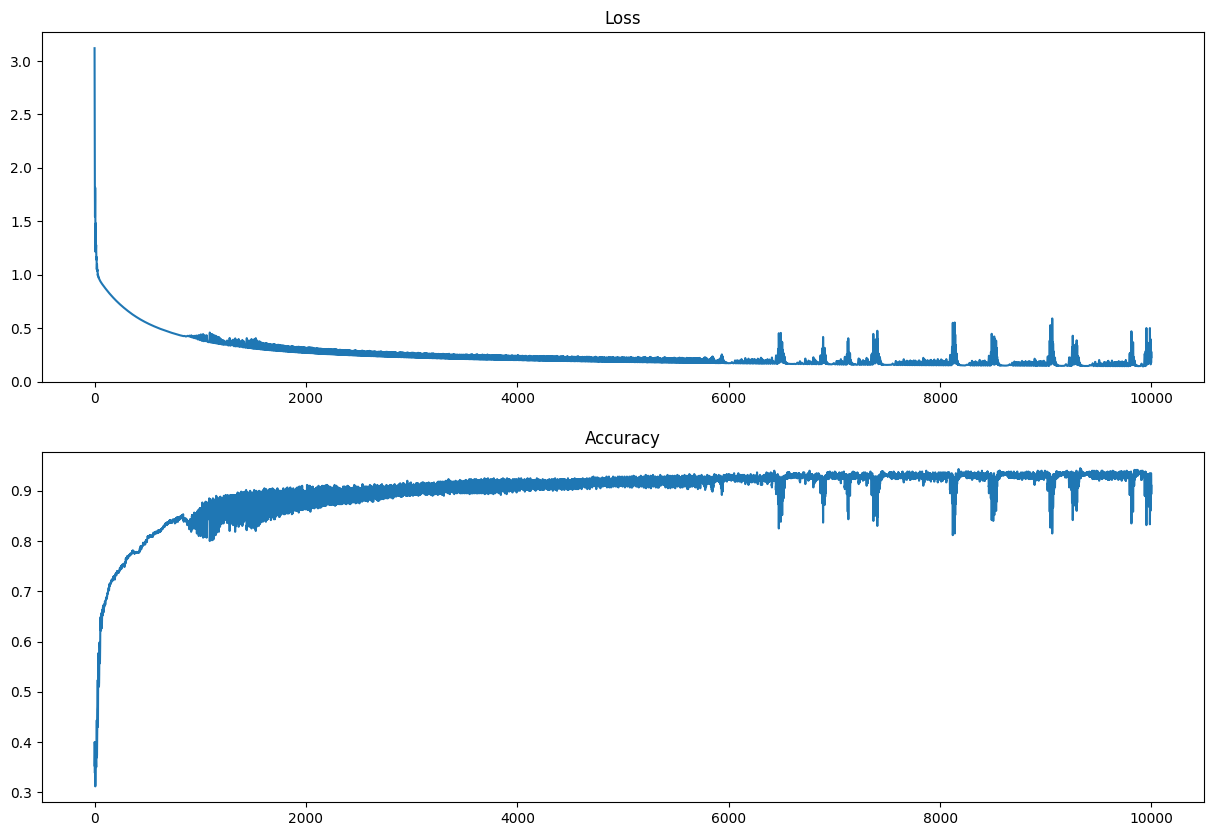

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10))
ax[0].plot(monitor[:, 0])
ax[0].set_title("Loss")
ax[1].plot(monitor[:, 1])
ax[1].set_title("Accuracy")

## Trying the ANN Model


In [ ]:
def get_y_pred(x):
    dense1.forward(x)
    relu.forward(dense1.output)
    dense2.forward(relu.output)
    softmax_loss.activation.forward(dense2.output)
    return softmax_loss.activation.output

In [ ]:
x_dummy = np.array([[0.1, 0.2]])
x_dummy.shape

(1, 2)

In [ ]:
y_pred = get_y_pred(x_dummy)
y_pred

array([[3.02212206e-04, 9.97658677e-01, 2.03911062e-03]])

In [ ]:
np.argmax(y_pred, axis=1)

array([1])